# Linear Regression — Practice Notebook

Fit a linear regression model with PyTorch on a synthetic dataset: generate the data, train with a manual training loop, and compare the learned parameters against the ground truth.

## Setup

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from dl_roadmap.data import make_synthetic_regression_dataset
from dl_roadmap.engine import Trainer, TrainerConfig
from dl_roadmap.utils import LoggerConfig, seed_everything, setup_logger
from dl_roadmap.visualization import plot_training_history

In [4]:
%matplotlib inline

pd.set_option("display.width", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)

seed_everything()
setup_logger(LoggerConfig(disable_logging=True))

## Dataset

In [5]:
# Generate dataset
X_train, X_val, y_train, y_val, real_coef, real_bias = (
    make_synthetic_regression_dataset()
)

# Dataset loaders
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=25,
    shuffle=True,
    drop_last=False,
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    shuffle=False,
)

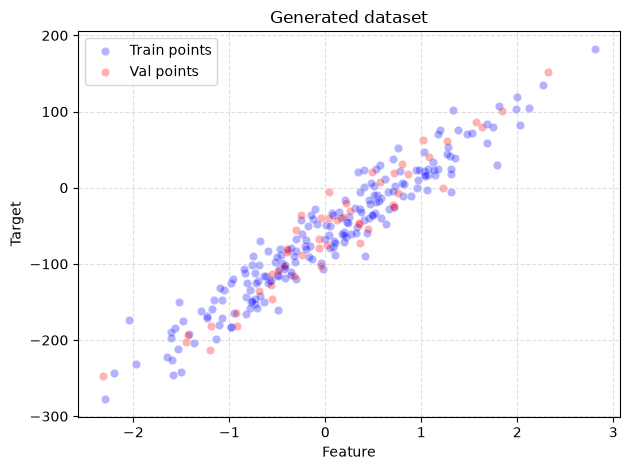

In [6]:
sns.scatterplot(
    x=X_train.flatten(),
    y=y_train.flatten(),
    alpha=0.3,
    label="Train points",
    c="b",
)
sns.scatterplot(
    x=X_val.flatten(),
    y=y_val.flatten(),
    alpha=0.3,
    label="Val points",
    c="r",
)
plt.title("Generated dataset")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Training

In [7]:
model = nn.Linear(1, 1)

opt = torch.optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

trainer_config = TrainerConfig(epochs=250)
trainer = Trainer(model, opt, loss_fn, config=trainer_config)
trainer.fit(train_loader, val_loader)

Epoch 250/250: 100%[====================] 2000/2000 :: eta=00:00, train_loss=546.3, val_loss=598.1


## Results

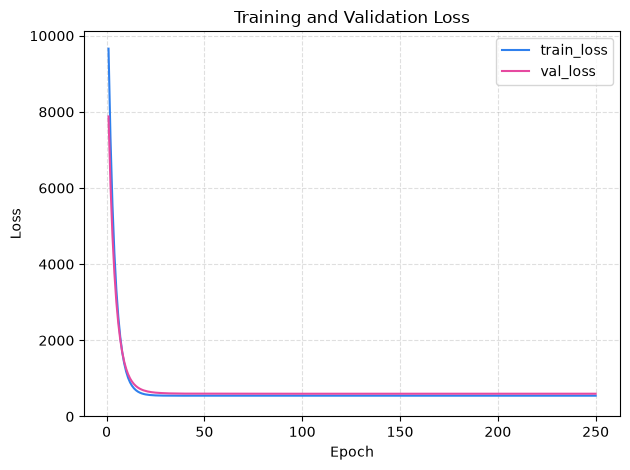

In [8]:
plot_training_history(**trainer.history)

In [9]:
pd.DataFrame(
    data={
        "coef": [float(real_coef), model.weight.detach().item()],
        "bias": [real_bias, model.bias.detach().item()],
    },
    index=["real", "pytorch"],
)

,coef,bias
real,88.226929,-63.815422
pytorch,84.856812,-64.020859


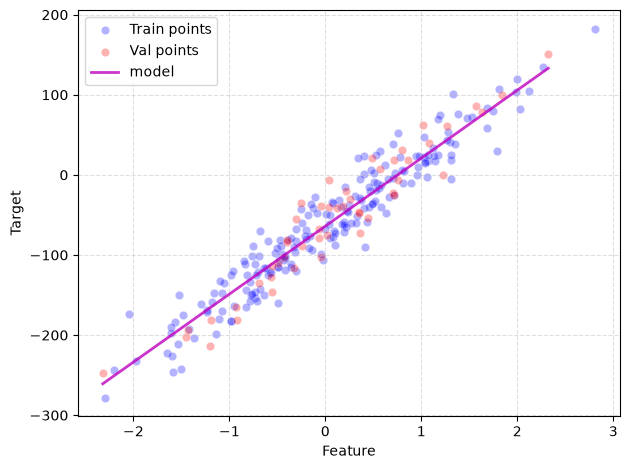

In [16]:
model_predictions = model(X_val).detach()

sns.scatterplot(
    x=X_train.flatten(),
    y=y_train.flatten(),
    alpha=0.3,
    label="Train points",
    c="b",
)
sns.scatterplot(
    x=X_val.flatten(),
    y=y_val.flatten(),
    alpha=0.3,
    label="Val points",
    c="r",
)
sns.lineplot(
    x=X_val.numpy().flatten(),
    y=model_predictions.numpy().flatten(),
    color="m",
    label="model",
    alpha=0.8,
    markersize=8,
    linewidth=2,
)

plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()